
Name: Yamini M
Reg No: 24BAD131

Support = 0.2
     support                     itemsets
0   0.571429                       (beer)
1   0.857143                      (bread)
2   0.714286                     (butter)
3   0.571429                       (milk)
4   0.571429                (beer, bread)
5   0.285714               (beer, butter)
6   0.285714                 (beer, milk)
7   0.571429              (bread, butter)
8   0.428571                (bread, milk)
9   0.571429               (milk, butter)
10  0.285714        (beer, bread, butter)
11  0.285714          (beer, milk, bread)
12  0.285714         (beer, milk, butter)
13  0.428571        (bread, milk, butter)
14  0.285714  (beer, milk, bread, butter)

Support = 0.4
    support               itemsets
0  0.571429                 (beer)
1  0.857143                (bread)
2  0.714286               (butter)
3  0.571429                 (milk)
4  0.571429          (beer, bread)
5  0.571429        (bread, butter)
6  0.428571         

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


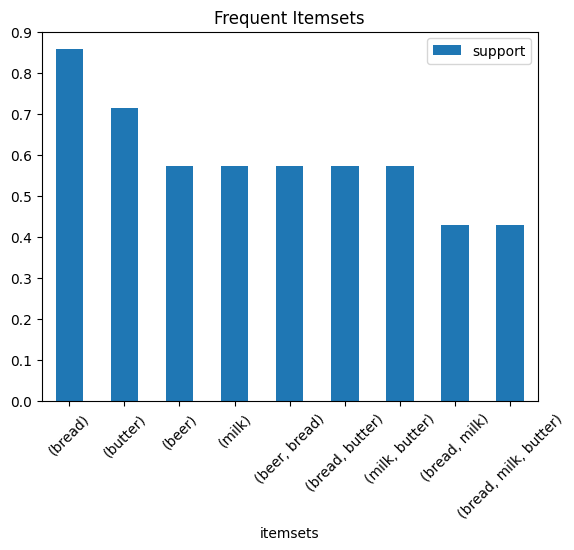

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


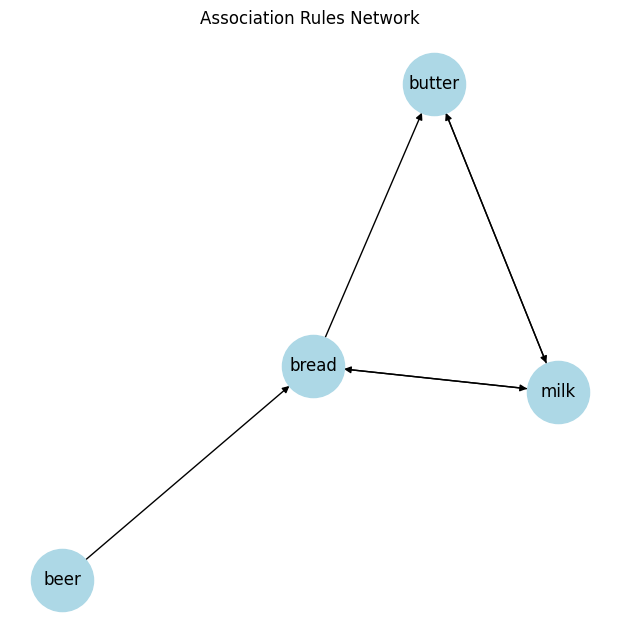

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


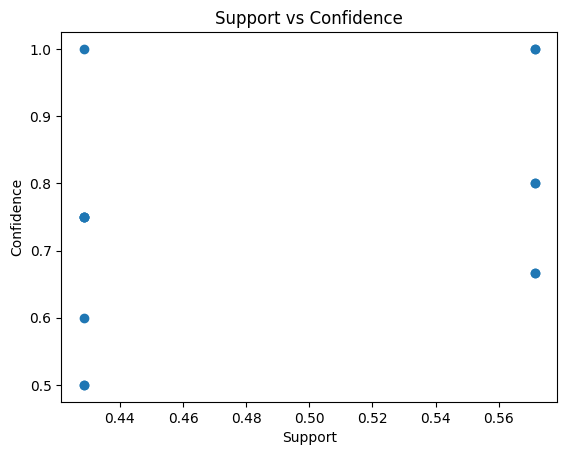

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

print("\nName: Yamini M")
print("Reg No: 24BAD131")

transactions = [
    ['milk', 'bread', 'butter'],
    ['beer', 'bread'],
    ['milk', 'bread', 'beer', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread', 'butter', 'beer'],
    ['milk', 'butter'],
    ['bread', 'beer'],
]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

supports = [0.2, 0.4, 0.6]

for s in supports:
    itemsets = apriori(df, min_support=s, use_colnames=True)
    print(f"\nSupport = {s}")
    print(itemsets)

frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
print("\nFrequent Itemsets:\n", frequent_itemsets)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print("\nAll Rules:\n", rules)

strong_rules = rules[(rules['confidence'] > 0.7) & (rules['lift'] > 1)]
print("\nStrong Rules:\n", strong_rules)

rules_low = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules_high = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

print("\nRules (Confidence ≥ 0.5):", len(rules_low))
print("Rules (Confidence ≥ 0.8):", len(rules_high))

frequent_itemsets.sort_values(by='support', ascending=False).plot(
    x='itemsets', y='support', kind='bar'
)
plt.title("Frequent Itemsets")
plt.xticks(rotation=45)
plt.show()

G = nx.DiGraph()

for _, row in strong_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['confidence'])

plt.figure(figsize=(6,6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)
plt.title("Association Rules Network")
plt.show()

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Name: Yamini M
Reg No: 24BAD131
Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


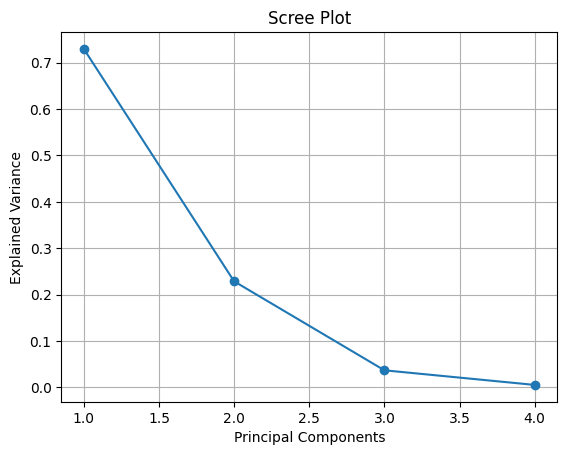

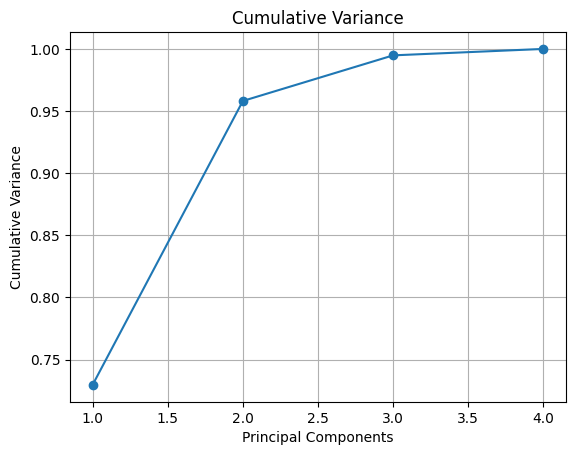

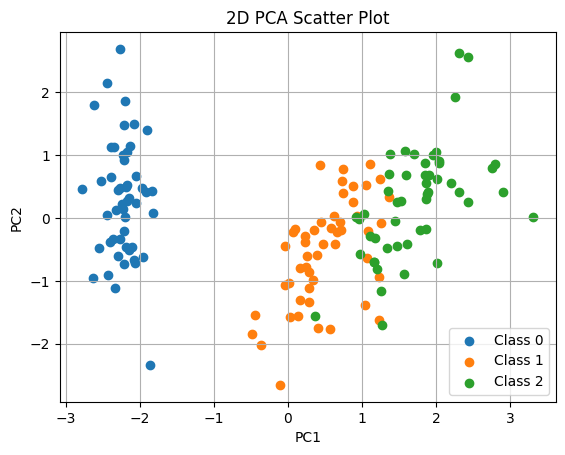

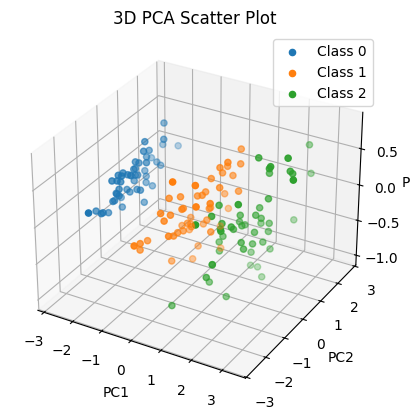


Optimal number of components (>=95% variance): 2


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

print("\nName: Yamini M")
print("Reg No: 24BAD131")

data = load_iris()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Dataset Preview:")
print(df.head())

df = df.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:, :-1])

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio:")
print(explained_variance)

print("\nCumulative Variance:")
print(cumulative_variance)

plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.grid()
plt.show()

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure()
for i in np.unique(y):
    plt.scatter(X_pca_2[y == i, 0], X_pca_2[y == i, 1], label=f"Class {i}")
plt.title("2D PCA Scatter Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in np.unique(y):
    ax.scatter(X_pca_3[y == i, 0],
               X_pca_3[y == i, 1],
               X_pca_3[y == i, 2],
               label=f"Class {i}")

ax.set_title("3D PCA Scatter Plot")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nOptimal number of components (>=95% variance): {optimal_components}")